# Notebook de evaluacion del caso de mejor desepeño:
* Agente AC para ctrl y orch
* 15000 episodios
* orch_freq= 1
* max_steps = 200
* range target = (0.05,0.9)

In [1]:
import os
import random
import numpy as np
import torch
import wandb
import sys
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Clonar desde Github:
!git clone https://github.com/valeriaeskenazi/Control-PID-Adaptativo-Inteligente-mediante-Reinforcement-Learning.git
PROJECT_PATH = '/content/Control-PID-Adaptativo-Inteligente-mediante-Reinforcement-Learning/Version_4'
sys.path.append(PROJECT_PATH)

Cloning into 'Control-PID-Adaptativo-Inteligente-mediante-Reinforcement-Learning'...
remote: Enumerating objects: 1663, done.
remote: Counting objects: 100% (223/223), done.
remote: Compressing objects: 100% (151/151), done.
remote: Total 1663 (delta 136), reused 153 (delta 71), pack-reused 1440 (from 1)
Receiving objects: 100% (1663/1663), 37.90 MiB | 21.75 MiB/s, done.
Resolving deltas: 100% (1000/1000), done.


In [3]:
from Environment.Simulation_Env.Reactor_CSTR import CSTRSimulator
from Environment.PIDControlEnv_simple import PIDControlEnv_Simple
from Environment.PIDControlEnv_complex import PIDControlEnv_Complex
from Agente.Actor_Critic.train_AC import ACTrainer
from Agente.Actor_Critic.algorithm_AC import ACAgent
from Aux.Plots import SimplePlotter, print_summary

print('Imports completados')
print(f'PyTorch: {torch.__version__}')
print(f'Device: {"CUDA" if torch.cuda.is_available() else "CPU"}')

Imports completados
PyTorch: 2.10.0+cpu
Device: CPU


In [4]:
gpu_info = !nvidia-smi
gpu_info = '\n'.join(gpu_info)
if gpu_info.find('failed') >= 0:
    print('Not connected to a GPU')
else:
    print(gpu_info)

/bin/bash: line 1: nvidia-smi: command not found


In [5]:
#fijo semilla para reproducibilidad
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

## 2. Login W&B

In [6]:
!pip install wandb --quiet

In [7]:
wandb.login()

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

 ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: ve326684 (ve326684-universidad-ort-uruguay) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

##3. Desacarga de pesos

In [9]:
api = wandb.Api()
artifact = api.artifact('ve326684-universidad-ort-uruguay/Tesis_AC_ORCH_15K_V11/model_ac_orch_15k_run-v11:latest')
artifact_dir = artifact.download()

wandb:   6 of 6 files downloaded.  


##4. Crear agente con pesos "best"

In [10]:
DEVICE             = 'cuda' if torch.cuda.is_available() else 'cpu'
MANIPULABLE_RANGES = [(300, 420), (99.5, 104)]
ORCH_FREQ          = 1
MAX_STEPS          = 200

eval_config = {
    'env_config': {
        'architecture'             : 'jerarquica',
        'env_type'                 : 'simulation',
        'n_manipulable_vars'       : 2,
        'manipulable_ranges'       : MANIPULABLE_RANGES,
        'n_target_vars'            : 1,
        'target_ranges'            : [(0.05, 0.9)],
        'target_setpoints'         : [0.4],
        'target_working_ranges'    : [(0.0, 2.0)],
        'dt_usuario'               : 1.0,
        'max_steps'                : MAX_STEPS,
        'orch_freq'                : ORCH_FREQ,
        'max_time_detector'        : 200,
        'reward_dead_band'         : 0.02,
        'delta_percent_ctrl'       : 0.05,
        'delta_percent_orch'       : 0.05,
        'reward_weights'           : {'error': 1.0, 'tiempo': 0.001, 'overshoot': 0.3, 'energy': 0.001},
        'pid_limits'               : [(0.01, 5.0), (0.001, 1.0), (0.0, 1.0)],
        'agent_orchestrator_config': {'agent_type': 'continuous'},
        'env_type_config'          : {'dt': 1.0, 'control_limits': (MANIPULABLE_RANGES[0], MANIPULABLE_RANGES[1])},
        'stability_config'         : {
            'error_increase_tolerance': 2.0,
            'max_sign_changes_ratio'  : 0.2,
            'max_abrupt_change_ratio' : 0.05,
            'abrupt_change_threshold' : 0.5,
        },
    },
    'ctrl_checkpoint_path': f'{artifact_dir}/agent_ctrl_best.pt',
    'agent_ctrl_config': {
        'algorithm'  : 'ac',
        'state_dim'  : 10,
        'action_dim' : 6,
        'n_vars'     : 2,
        'action_type': 'continuous',
        'hidden_dims': (256, 128, 64),
        'device'     : DEVICE,
    },
    'agent_orch_config': {
        'algorithm'    : 'ac',
        'state_dim'    : 7,
        'action_dim'   : 2,
        'n_vars'       : 2,
        'action_type'  : 'continuous',
        'hidden_dims'  : (64, 32),
        'lr_actor'     : 2e-05,
        'lr_critic'    : 1e-03,
        'gamma'        : 0.9,
        'entropy_coef' : 0.15,
        'batch_size'   : 64,
        'buffer_size'  : 10000,
        'warmup_steps' : 200,
        'device'       : DEVICE,
        'seed'         : 42,
    },
    'n_episodes'                  : 1,
    'max_steps_per_episode'       : MAX_STEPS,
    'eval_frequency'              : 9999,
    'log_frequency'               : 1,
    'save_frequency'              : 9999,
    'checkpoint_dir'              : 'checkpoints/eval_tmp',
    'early_stopping_patience'     : 9999,
    'early_stopping_min_delta_pct': 0.01,
    'use_wandb'                   : False,
}

cstr = CSTRSimulator(dt=1.0, control_limits=(MANIPULABLE_RANGES[0], MANIPULABLE_RANGES[1]))
trainer_eval = ACTrainer(eval_config)
trainer_eval.env.proceso.connect_external_process(cstr)
trainer_eval.agent_orch.load(f'{artifact_dir}/agent_orch_best.pt')
print('Agentes cargados')
print(f'orch_freq={ORCH_FREQ} | max_steps={MAX_STEPS}')

Cargando agente CTRL pre-entrenado desde: /content/artifacts/model_ac_orch_15k_run-v11:v3/agent_ctrl_best.pt
AC Estocástico creado | role=ctrl | state=10 | action=6 | device=cpu
AC Agent cargado desde: /content/artifacts/model_ac_orch_15k_run-v11:v3/agent_ctrl_best.pt
AC Estocástico creado | role=orch | state=7 | action=2 | device=cpu
AC Agent cargado desde: /content/artifacts/model_ac_orch_15k_run-v11:v3/agent_orch_best.pt
Agentes cargados
orch_freq=1 | max_steps=200


###4.1. Funcion de evaluación para diferentes SP

In [11]:
def evaluar_cb(trainer, cb_sp, max_steps=None):
    if max_steps is None:
        max_steps = trainer.env.max_steps

    obs, _ = trainer.env.reset()
    trainer.env.target_setpoints = [cb_sp]
    trainer.env._update_errors()

    cstr   = trainer.env.proceso.external_process
    print(f'\nSP_Cb={cb_sp} | Estado inicial: Cb={cstr.state[1]:.3f} | T={cstr.state[3]:.1f}K | V={cstr.state[4]:.2f}m³')

    cb_traj, T_traj, V_traj = [cstr.state[1]], [cstr.state[3]], [cstr.state[4]]
    SP_T_traj, SP_V_traj    = [], []   # trayectoria de SPs que pide el ORCH

    state_ctrl = obs['ctrl']
    state_orch = obs['orch']
    done       = False
    step       = 0

    while not done and step < max_steps:
        action_orch = trainer.agent_orch.select_action(state_orch, training=False)
        action_ctrl = trainer.agent_ctrl.select_action(state_ctrl, training=False)
        action      = {'ctrl': action_ctrl, 'orch': action_orch}

        next_obs, reward, terminated, truncated, info = trainer.env.step(action)
        done = terminated or truncated

        # Registrar SPs solo cuando el ORCH actuó
        if info.get('orch_acted', False):
            SP_T_traj.append(trainer.env.new_SP[0])
            SP_V_traj.append(trainer.env.new_SP[1])
            print(f'  Step {step:3d} | ORCH actúa → SP_T={trainer.env.new_SP[0]:.1f}K  SP_V={trainer.env.new_SP[1]:.2f}m³ | Cb={cstr.state[1]:.4f}')

        cb_traj.append(cstr.state[1])
        T_traj.append(cstr.state[3])
        V_traj.append(cstr.state[4])

        state_ctrl = next_obs['ctrl']
        state_orch = next_obs['orch']
        step      += 1

    cb_final = cb_traj[-1]
    print(f'Cb_final={cb_final:.4f} | Error={abs(cb_final - cb_sp):.4f}')
    return np.array(cb_traj), np.array(T_traj), np.array(V_traj), SP_T_traj, SP_V_traj

####4.1.1 Graficos para ajuste de diferentes SP


SP_Cb=0.2 | Estado inicial: Cb=0.435 | T=340.0K | V=102.00m³
  Step   0 | ORCH actúa → SP_T=332.7K  SP_V=102.59m³ | Cb=0.2177
  Step   1 | ORCH actúa → SP_T=332.1K  SP_V=102.36m³ | Cb=0.2141
  Step   2 | ORCH actúa → SP_T=329.5K  SP_V=102.14m³ | Cb=0.1850
  Step   3 | ORCH actúa → SP_T=330.1K  SP_V=101.92m³ | Cb=0.1850
  Step   4 | ORCH actúa → SP_T=329.7K  SP_V=101.69m³ | Cb=0.1850
  Step   5 | ORCH actúa → SP_T=329.1K  SP_V=101.47m³ | Cb=0.1775
  Step   6 | ORCH actúa → SP_T=329.3K  SP_V=101.24m³ | Cb=0.1775
  Step   7 | ORCH actúa → SP_T=329.0K  SP_V=101.02m³ | Cb=0.1775
  Step   8 | ORCH actúa → SP_T=328.8K  SP_V=100.80m³ | Cb=0.1715
  Step   9 | ORCH actúa → SP_T=329.1K  SP_V=100.58m³ | Cb=0.1715
  Step  10 | ORCH actúa → SP_T=329.1K  SP_V=100.35m³ | Cb=0.1696
  Step  11 | ORCH actúa → SP_T=329.3K  SP_V=100.13m³ | Cb=0.1696
  Step  12 | ORCH actúa → SP_T=329.5K  SP_V=99.91m³ | Cb=0.1707
  Step  13 | ORCH actúa → SP_T=329.6K  SP_V=99.69m³ | Cb=0.1707
  Step  14 | ORCH actúa → SP_T

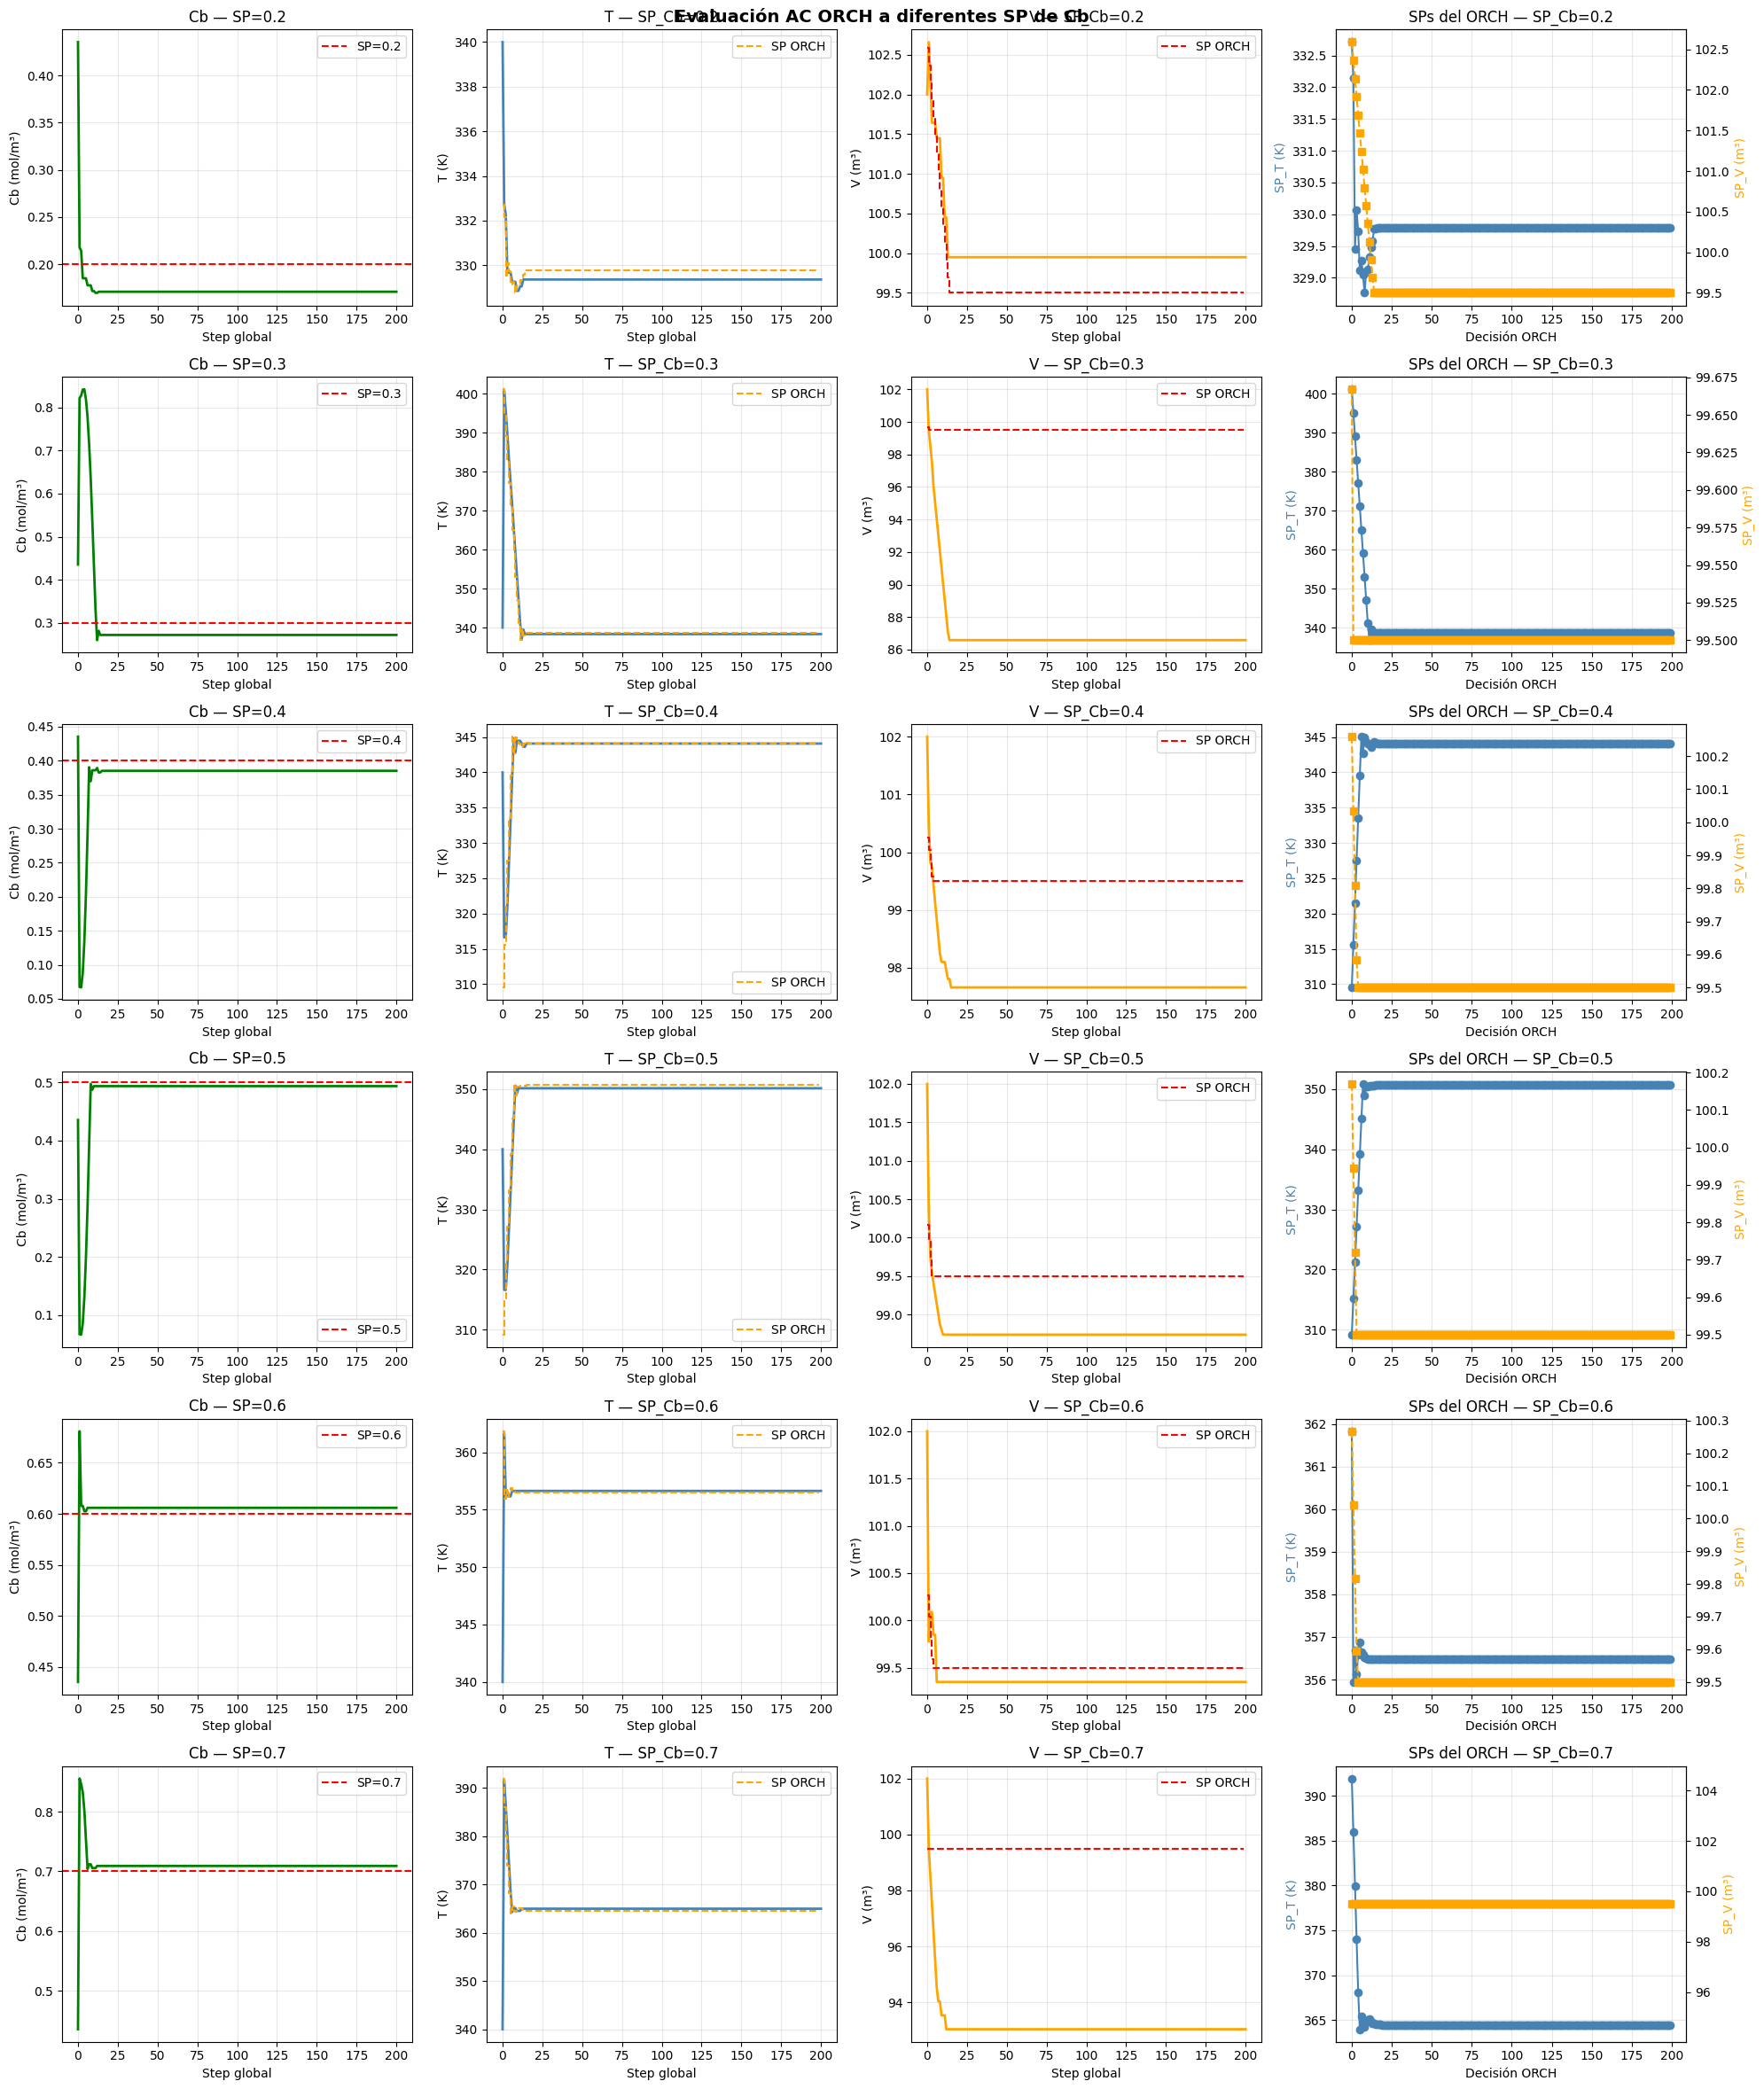

In [12]:
Cb_setpoints = [0.2, 0.3, 0.4, 0.5, 0.6, 0.7]

fig, axes = plt.subplots(len(Cb_setpoints), 4, figsize=(20, 4 * len(Cb_setpoints)))

for i, cb_sp in enumerate(Cb_setpoints):
    cb_traj, T_traj, V_traj, SP_T, SP_V = evaluar_cb(trainer_eval, cb_sp)
    steps = np.arange(len(cb_traj))

    # Cb
    axes[i, 0].plot(steps, cb_traj, color='green', linewidth=2)
    axes[i, 0].axhline(cb_sp, color='red', linestyle='--', linewidth=1.5, label=f'SP={cb_sp}')
    axes[i, 0].set_title(f'Cb — SP={cb_sp}')
    axes[i, 0].set_ylabel('Cb (mol/m³)')
    axes[i, 0].legend(); axes[i, 0].grid(True, alpha=0.3)

    # T con los SPs que pidió el ORCH marcados
    axes[i, 1].plot(steps, T_traj, color='steelblue', linewidth=2)
    if SP_T:
        sp_steps = [j * ORCH_FREQ for j in range(len(SP_T))]
        axes[i, 1].step(sp_steps, SP_T, color='orange', linewidth=1.5,
                        linestyle='--', where='post', label='SP ORCH')
        axes[i, 1].legend()
    axes[i, 1].set_title(f'T — SP_Cb={cb_sp}')
    axes[i, 1].set_ylabel('T (K)'); axes[i, 1].grid(True, alpha=0.3)

    # V con los SPs que pidió el ORCH marcados
    axes[i, 2].plot(steps, V_traj, color='orange', linewidth=2)
    if SP_V:
        sp_steps = [j * ORCH_FREQ for j in range(len(SP_V))]
        axes[i, 2].step(sp_steps, SP_V, color='red', linewidth=1.5,
                        linestyle='--', where='post', label='SP ORCH')
        axes[i, 2].legend()
    axes[i, 2].set_title(f'V — SP_Cb={cb_sp}')
    axes[i, 2].set_ylabel('V (m³)'); axes[i, 2].grid(True, alpha=0.3)

    # SPs del ORCH a lo largo del episodio
    if SP_T and SP_V:
        dec_idx = np.arange(len(SP_T))
        axes[i, 3].plot(dec_idx, SP_T, 'o-', color='steelblue', label='SP_T')
        ax2 = axes[i, 3].twinx()
        ax2.plot(dec_idx, SP_V, 's--', color='orange', label='SP_V')
        axes[i, 3].set_title(f'SPs del ORCH — SP_Cb={cb_sp}')
        axes[i, 3].set_xlabel('Decisión ORCH')
        axes[i, 3].set_ylabel('SP_T (K)', color='steelblue')
        ax2.set_ylabel('SP_V (m³)', color='orange')
        axes[i, 3].grid(True, alpha=0.3)

    for ax in axes[i, :3]:
        ax.set_xlabel('Step global')

plt.suptitle('Evaluación AC ORCH a diferentes SP de Cb', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eval_ac_orch__diferents_Cb', dpi=150, bbox_inches='tight')
plt.show()

###4.2. Comparacion de escenarios con paper (figuras 7 del paper)

####4.2.1 Funcion de evaluacion

In [13]:
def evaluar_paper_freq(trainer, sp_sequence=[0.075, 0.45, 0.75],
                       steps_per_sp=40, orch_freq=7):

    cstr = trainer.env.proceso.external_process

    # Estado inicial del paper
    cstr.state = np.array([0.0, 0.0, 0.0, 327.0, 102.0])
    cstr.Tc_current = cstr.Tc_initial
    cstr.F_current  = cstr.F_initial

    # Reset y sobreescribir con estado del paper
    trainer.env.reset()
    trainer.env.orch_freq = orch_freq  # sobreescribir frecuencia
    trainer.env._orch_step_count = 0
    trainer.env.manipulable_pvs = list(cstr.get_initial_pvs())
    trainer.env.proceso.manipulable_pvs = trainer.env.manipulable_pvs.copy()
    trainer.env.target_pvs = [float(cstr.state[1])]
    trainer.env.target_setpoints = [sp_sequence[0]]
    trainer.env.current_SPs_manipulable = trainer.env.manipulable_pvs.copy()
    trainer.env.new_SP = trainer.env.manipulable_pvs.copy()
    trainer.env._update_errors()

    obs = trainer.env._get_observation()
    state_orch = obs['orch']
    state_ctrl = obs['ctrl']

    cb_traj = [float(cstr.state[1])]
    T_traj  = [float(cstr.state[3])]
    V_traj  = [float(cstr.state[4])]
    sp_traj = [sp_sequence[0]]
    Tc_traj = [float(cstr.Tc_current)]

    total_steps = steps_per_sp * len(sp_sequence)

    for step in range(total_steps):
        sp_idx = min(step // steps_per_sp, len(sp_sequence) - 1)
        trainer.env.target_setpoints = [sp_sequence[sp_idx]]

        action_orch = trainer.agent_orch.select_action(state_orch, training=False)
        action_ctrl = trainer.agent_ctrl.select_action(state_ctrl, training=False)

        next_obs, reward, terminated, truncated, info = trainer.env.step(
            {'ctrl': action_ctrl, 'orch': action_orch}
        )

        cb_traj.append(float(cstr.state[1]))
        T_traj.append(float(cstr.state[3]))
        V_traj.append(float(cstr.state[4]))
        sp_traj.append(sp_sequence[sp_idx])
        Tc_traj.append(float(cstr.Tc_current))

        state_orch = next_obs['orch']
        state_ctrl = next_obs['ctrl']

    return (np.array(cb_traj), np.array(T_traj), np.array(V_traj),
            np.array(sp_traj), np.array(Tc_traj))

####4.2.2 Graficos

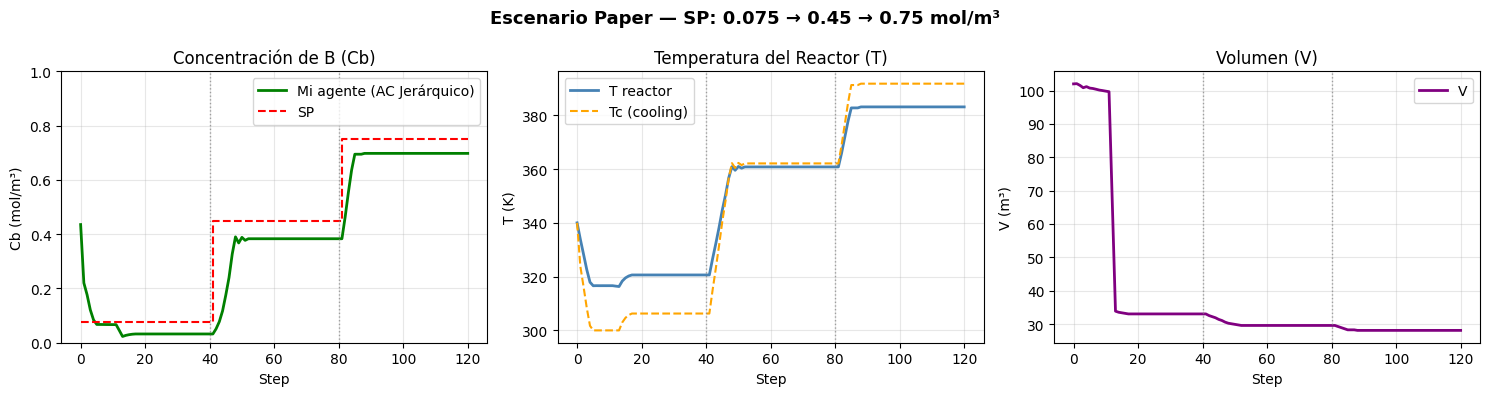


Errores por setpoint:
  SP=0.075 → Cb=0.0323 | Error=0.0427
  SP=0.45 → Cb=0.3831 | Error=0.0669
  SP=0.75 → Cb=0.6977 | Error=0.0523


In [14]:
# ============ EVALUACIÓN ESCENARIO PAPER — FIGURA 7 ============
cb, T, V, sp, Tc = evaluar_paper_freq(
    trainer_eval,
    sp_sequence=[0.075, 0.45, 0.75],
    steps_per_sp=40,
    orch_freq=1
)

steps = np.arange(len(cb))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# --- Cb vs SP (el gráfico principal para comparar con el paper) ---
axes[0].plot(steps, cb, color='green', linewidth=2, label='Mi agente (AC Jerárquico)')
axes[0].step(steps, sp, color='red', linestyle='--', linewidth=1.5, where='post', label='SP')
axes[0].set_title('Concentración de B (Cb)')
axes[0].set_ylabel('Cb (mol/m³)')
axes[0].set_xlabel('Step')
axes[0].set_ylim(0, 1)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# --- Temperatura del reactor ---
axes[1].plot(steps, T, color='steelblue', linewidth=2, label='T reactor')
axes[1].plot(steps, Tc, color='orange', linestyle='--', linewidth=1.5, label='Tc (cooling)')
axes[1].set_title('Temperatura del Reactor (T)')
axes[1].set_ylabel('T (K)')
axes[1].set_xlabel('Step')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# --- Volumen ---
axes[2].plot(steps, V, color='purple', linewidth=2, label='V')
axes[2].set_title('Volumen (V)')
axes[2].set_ylabel('V (m³)')
axes[2].set_xlabel('Step')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

# Líneas verticales marcando cambios de SP
for ax in axes:
    ax.axvline(x=40, color='gray', linestyle=':', linewidth=1, alpha=0.7)
    ax.axvline(x=80, color='gray', linestyle=':', linewidth=1, alpha=0.7)

plt.suptitle('Escenario Paper — SP: 0.075 → 0.45 → 0.75 mol/m³',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('eval_escenario_paper.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Errores por SP ---
print("\nErrores por setpoint:")
for i, s in enumerate([0.075, 0.45, 0.75]):
    idx = min((i+1)*40, len(cb)-1)
    print(f"  SP={s} → Cb={cb[idx]:.4f} | Error={abs(cb[idx]-s):.4f}")

###4.3 Graficar diferentes frecuencias de orch

Corriendo orch_freq=1...
  SP=0.075 → Cb=0.0470 | Error=0.0280
  SP=0.45 → Cb=0.4205 | Error=0.0295
  SP=0.75 → Cb=0.7385 | Error=0.0115
Corriendo orch_freq=3...
  SP=0.075 → Cb=0.0502 | Error=0.0248
  SP=0.45 → Cb=0.3810 | Error=0.0690
  SP=0.75 → Cb=0.7345 | Error=0.0155
Corriendo orch_freq=5...
  SP=0.075 → Cb=0.0673 | Error=0.0077
  SP=0.45 → Cb=0.4351 | Error=0.0149
  SP=0.75 → Cb=0.7275 | Error=0.0225
Corriendo orch_freq=7...
  SP=0.075 → Cb=0.0695 | Error=0.0055
  SP=0.45 → Cb=0.4984 | Error=0.0484
  SP=0.75 → Cb=0.7523 | Error=0.0023


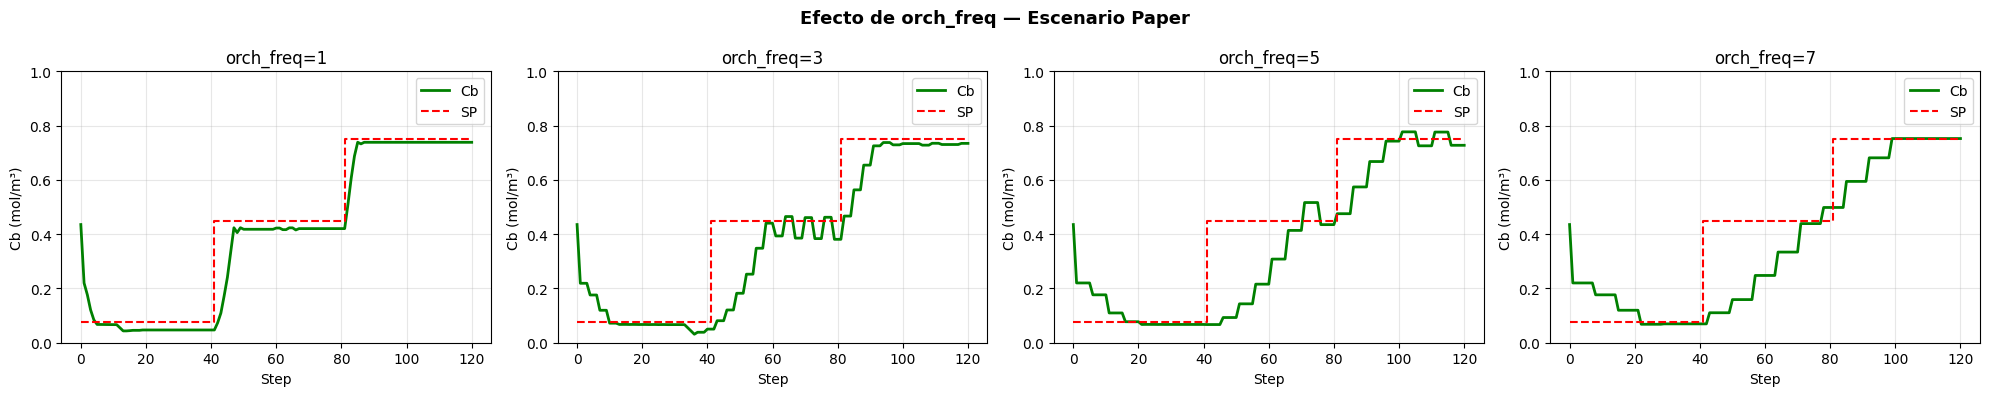

In [15]:
# ============ CORRER Y GRAFICAR DISTINTAS FRECUENCIAS ============
freqs_test = [1, 3, 5, 7]
sp_sequence  = [0.075, 0.45, 0.75]
steps_per_sp = 40

resultados = {}
for freq in freqs_test:
    print(f"Corriendo orch_freq={freq}...")
    cb, T, V, sp, Tc = evaluar_paper_freq(trainer_eval, sp_sequence, steps_per_sp, freq)
    resultados[freq] = {'cb': cb, 'T': T, 'V': V, 'sp': sp, 'Tc': Tc}
    for i, s in enumerate(sp_sequence):
        idx = min((i+1)*steps_per_sp, len(cb)-1)
        print(f"  SP={s} → Cb={cb[idx]:.4f} | Error={abs(cb[idx]-s):.4f}")

# Graficar Cb para todas las frecuencias
fig, axes = plt.subplots(1, len(freqs_test), figsize=(5*len(freqs_test), 4))
steps = np.arange(steps_per_sp * len(sp_sequence) + 1)

for ax, freq in zip(axes, freqs_test):
    r = resultados[freq]
    ax.plot(steps, r['cb'], color='green', linewidth=2, label='Cb')
    ax.step(steps, r['sp'], color='red', linestyle='--', linewidth=1.5,
            where='post', label='SP')
    ax.set_title(f'orch_freq={freq}')
    ax.set_ylabel('Cb (mol/m³)')
    ax.set_xlabel('Step')
    ax.legend(); ax.grid(True, alpha=0.3)
    ax.set_ylim(0, 1)

plt.suptitle('Efecto de orch_freq — Escenario Paper', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('comparacion_orch_freq.png', dpi=150, bbox_inches='tight')
plt.show()